In [1]:
%pip install pandas


Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


# Task 2 — Exploratory Data Analysis

## Bank Marketing Dataset

This analysis explores the cleaned Bank Marketing dataset from Task 1.
The objective is to calculate important statistics, identify trends,
patterns and anomalies, and present useful insights using charts.

Dataset Shape: (4521, 17)

Columns:
Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

Missing Values:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

Statistical Summary:
               age       balance          day     duration     campaign  \
count  4521.000000   4521.000000  4521.000000  4521.000000  4521.000000   
mean     41.170095   1422.657819    15.915284   263.961292     2.793630   
std      10.576211   3009.638142     8.247667   259.856633     3.109807   
min      19.000000  -3313.000000     1.000000     4.000000     1.000000   
25%      33.000000     69.000000     9.000000   104.000000     1.00000

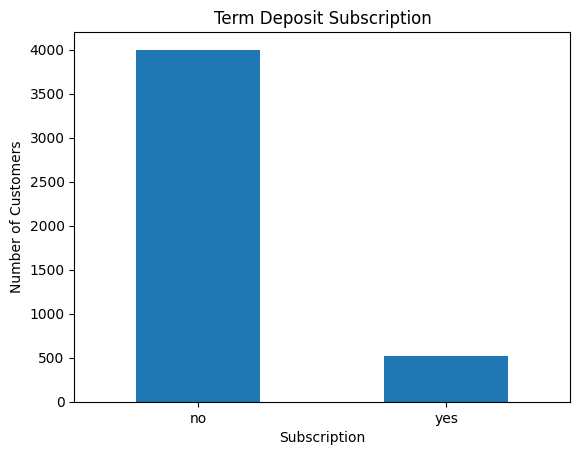


Subscription Rate by Job:
job
retired          23.478261
student          22.619048
management       13.704071
housemaid        12.500000
admin.           12.133891
self-employed    10.928962
technician       10.807292
unemployed       10.156250
services          9.112710
entrepreneur      8.928571
blue-collar       7.293869
Name: y, dtype: float64


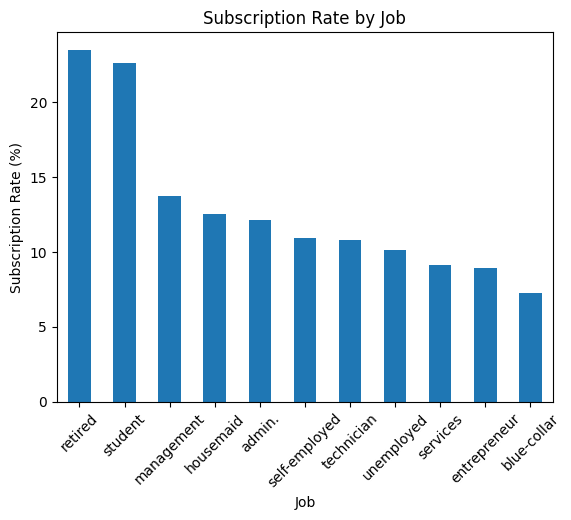


Subscription Rate by Month:
month
apr    19.112628
aug    12.480253
dec    45.000000
feb    17.117117
jan    10.810811
jul     8.640227
jun    10.357815
mar    42.857143
may     6.652361
nov    10.025707
oct    46.250000
sep    32.692308
Name: y, dtype: float64


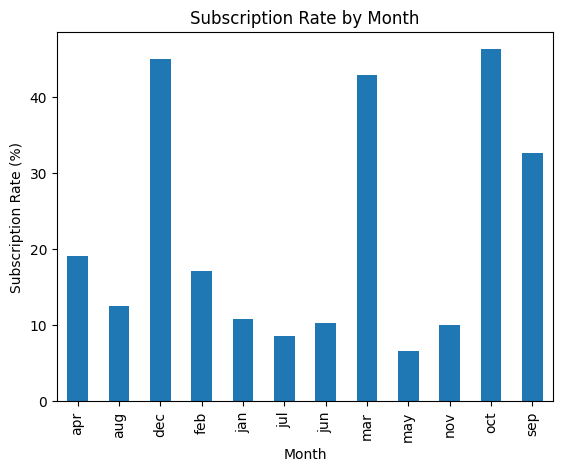


Subscription Rate by Previous Campaign Outcome:
poutcome
success    64.341085
other      19.289340
failure     9.535161
Name: y, dtype: float64

Subscription Rate by housing:
housing
no     15.341488
yes     8.597108
Name: y, dtype: float64

Subscription Rate by loan:
loan
no     12.480418
yes     6.222865
Name: y, dtype: float64

Duration by Subscription:
           mean  median   min     max
y                                    
no   226.347500   167.0   4.0  3025.0
yes  552.742802   442.0  30.0  2769.0


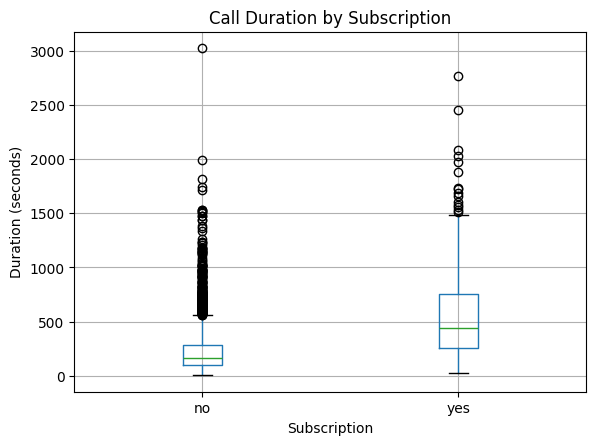

age: 38 potential outliers
balance: 506 potential outliers
duration: 330 potential outliers
campaign: 318 potential outliers
pdays: 816 potential outliers
previous: 816 potential outliers


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Load cleaned dataset
df = pd.read_csv("bank_marketing_cleaned.csv")

# -----------------------------
# 1. BASIC INFORMATION
# -----------------------------

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())

# -----------------------------
# 2. TARGET VARIABLE ANALYSIS
# -----------------------------

print("\nSubscription Count:")
print(df["y"].value_counts())

print("\nSubscription Percentage:")
print(df["y"].value_counts(normalize=True) * 100)

# Chart
df["y"].value_counts().plot(kind="bar")
plt.title("Term Deposit Subscription")
plt.xlabel("Subscription")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

# -----------------------------
# 3. JOB ANALYSIS
# -----------------------------

job_rate = df.groupby("job")["y"].apply(
    lambda x: (x == "yes").mean() * 100
).sort_values(ascending=False)

print("\nSubscription Rate by Job:")
print(job_rate)

job_rate.plot(kind="bar")
plt.title("Subscription Rate by Job")
plt.xlabel("Job")
plt.ylabel("Subscription Rate (%)")
plt.xticks(rotation=45)
plt.show()

# -----------------------------
# 4. MONTH ANALYSIS
# -----------------------------

month_rate = df.groupby("month")["y"].apply(
    lambda x: (x == "yes").mean() * 100
)

print("\nSubscription Rate by Month:")
print(month_rate)

month_rate.plot(kind="bar")
plt.title("Subscription Rate by Month")
plt.xlabel("Month")
plt.ylabel("Subscription Rate (%)")
plt.show()

# -----------------------------
# 5. PREVIOUS CAMPAIGN
# -----------------------------

poutcome_rate = df.groupby("poutcome")["y"].apply(
    lambda x: (x == "yes").mean() * 100
).sort_values(ascending=False)

print("\nSubscription Rate by Previous Campaign Outcome:")
print(poutcome_rate)

# -----------------------------
# 6. LOAN ANALYSIS
# -----------------------------

for column in ["housing", "loan"]:
    result = df.groupby(column)["y"].apply(
        lambda x: (x == "yes").mean() * 100
    )
    print(f"\nSubscription Rate by {column}:")
    print(result)

# -----------------------------
# 7. DURATION ANALYSIS
# -----------------------------

print("\nDuration by Subscription:")
print(df.groupby("y")["duration"].agg(["mean", "median", "min", "max"]))

df.boxplot(column="duration", by="y")
plt.title("Call Duration by Subscription")
plt.suptitle("")
plt.xlabel("Subscription")
plt.ylabel("Duration (seconds)")
plt.show()

# -----------------------------
# 8. OUTLIER DETECTION
# -----------------------------

numeric_columns = [
    "age", "balance", "duration",
    "campaign", "pdays", "previous"
]

for column in numeric_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower) |
        (df[column] > upper)
    ]

    print(
        f"{column}: {len(outliers)} potential outliers"
    )

## Key Insights

### Insight 1 — Overall Subscription Rate

Only 11.52% of customers subscribed to the term deposit,
while 88.48% did not subscribe. This indicates that the dataset
has a strong imbalance between the two subscription outcomes.

### Insight 2 — Call Duration

Customers who subscribed generally had longer call durations
than customers who did not subscribe. This indicates that longer
customer interactions were associated with higher subscription
rates in the dataset.

### Insight 3 — Previous Campaign Outcome

Customers with a successful previous campaign outcome showed
a substantially higher subscription rate than customers whose
previous campaign outcome was a failure or another outcome.

### Insight 4 — Job Category

Subscription rates varied across job categories. Retired and
student customers showed relatively high subscription rates,
while blue-collar customers showed a lower subscription rate.

### Insight 5 — Contact Month

Subscription rates varied considerably across contact months.
Some months showed much higher rates than others. However,
months with very few observations should be interpreted cautiously.

### Insight 6 — Housing Loan

Customers without a housing loan had a higher subscription rate
than customers with a housing loan in this dataset.

### Insight 7 — Balance Anomalies

The balance variable contains extreme values compared with the
middle 50% of observations. These potential outliers should be
investigated rather than automatically removed because they may
represent genuine customer balances.

## Conclusion

The exploratory analysis of the cleaned Bank Marketing dataset
revealed several important patterns. The overall subscription
rate was relatively low, with most customers not subscribing.
Subscription rates varied according to job, contact month,
previous campaign outcome and loan status. Call duration also
showed a noticeable difference between customers who subscribed
and those who did not.

The analysis identified potential outliers in numerical variables
such as balance, duration, campaign and age. These findings provide
useful information about customer behaviour and campaign outcomes
and can be used for further analysis and customer targeting.